# Feature Engineering

## What is Feature Engineering?

**Feature engineering** is the process of using domain knowledge to transform raw data into meaningful inputs (called *features*) for a machine learning model or statistical analysis.

Raw data on its own is rarely in a form that models can learn from directly. For example:
- A **timestamp** tells you when something happened — but your model cannot directly use `'2020-05-26 22:15:00'`. A more useful feature might be `days_before_deadline`.
- A **list of page visits** does not tell you much alone — but `total number of visits` or `time spent per assignment` are informative summaries.

In this lecture, we will practice feature engineering on a real dataset: **Canvas LMS log data** from an online programming course. Our goal is to build features that help explain why some students perform better on assignments than others.

---

### The three feature families we will explore today

| # | Feature family | Example | Intuition |
|---|---|---|---|
| 1 | **Count & time aggregates** | `totalCount`, `totalTime` | How much did the student engage overall? |
| 2 | **Temporal / day-based features** | `firstDay`, `nDays`, `nDaysFinalWeek` | *When* did the student work — did they cram or spread it out? |
| 3 | **Ratios** | `detailRatio` | What *proportion* of their time was spent on detail vs. overview pages? |

---

We continue from Week 4 where we computed `view_length` (capped at 30 minutes). Let's reload the data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

# Read the raw Canvas event log. Each record represents one observed page view,
# so this table is the starting point for turning click/activity behaviour into features.
log = pd.read_csv('transformed_dataset.csv')
print('Log shape:', log.shape)
print(log.head(10))

# Read the student outcome data. These grades become the target variables that
# we compare against the engineered activity features later in the notebook.
grades = pd.read_csv('grades_data.csv')
print('\nGrades shape:', grades.shape)
print(grades.head(10))


Log shape: (9829, 5)
   userID assignment                                                url  \
0  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
1  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
2  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
3  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
4  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-m...   
5  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
6  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
7  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   
8  100001         a1  https://canvas.sfu.ca/courses/46101/assignment...   
9  100001         a1  https://canvas.sfu.ca/courses/46101/pages/a1-o...   

                  start_time  view_length  
0  2026-05-20 16:19:42-07:00         22.0  
1  2026-05-20 16:20:49-07:00       1524.0  
2  2026-05-22 23:31:5

---
## Feature Family 1 — Count & Time Aggregates

The simplest features we can compute are **totals per student per assignment**:
- `totalCount` — how many times did the student visit any page for this assignment?
- `totalTime` — how many seconds in total did the student spend on those pages?

These are called **aggregation features**: we are collapsing many rows (individual page views) into one summary row per (student, assignment) pair.

> 💡 **Pandas pattern:** `groupby(['userID','assignment']).size()` counts rows per group.
> `.unstack()` pivots the `assignment` level into separate columns, giving one column per assignment.

In [2]:
# Count how often each student interacted with each assignment.
# The groupby creates one bucket per (userID, assignment), and size() turns each
# bucket into a simple visit count.
grouped = log.groupby(['userID', 'assignment']).size().unstack(fill_value=0)

# Keep assignment columns in a predictable order so later a1/a2/a3 comparisons
# line up cleanly across tables and plots.
grouped = grouped.reindex(sorted(grouped.columns), axis=1)

# Rename the columns to make the feature meaning explicit after merging.
grouped.columns = [f"{col}totalCount" for col in grouped.columns]

# Put userID back as a normal column because future joins use it as the key.
assignment_counts = grouped.reset_index()

print(f"Shape: {assignment_counts.shape}  ->  {assignment_counts.shape[0]} students, "
      f"{assignment_counts.shape[1]-1} count features + userID")
assignment_counts.head()


Shape: (54, 6)  ->  54 students, 5 count features + userID


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount
0,100001,38,37,37,61,48
1,100002,46,49,39,42,64
2,100003,38,33,37,24,29
3,100004,41,19,38,28,40
4,100005,27,52,51,27,51


Now let's do the same thing for **time**. Instead of counting rows, we *sum* the `view_length` column within each group.

> 💡 `groupby(...)[col].sum()` is a common pandas idiom for aggregating a specific numeric column.

In [3]:
# Sum the amount of recorded viewing time for each student-assignment pair.
# This uses the same shape as the count table, but measures duration instead of frequency.
time_totals = (
    log.groupby(['userID', 'assignment'])['view_length']
       .sum()
       .unstack(fill_value=0)
)
time_totals = time_totals.reindex(sorted(time_totals.columns), axis=1)
time_totals.columns = [f"{col}totalTime" for col in time_totals.columns]
time_totals = time_totals.reset_index()

# Combine the two first-pass feature tables. After this merge, each student has
# one row containing both visit counts and total time for every assignment.
assignments = pd.merge(assignment_counts, time_totals, on='userID', how='left')

print(f"Final shape: {assignments.shape}")
print("Columns:", assignments.columns.tolist())
assignments.head()


Final shape: (54, 11)
Columns: ['userID', 'a1totalCount', 'a2totalCount', 'a3totalCount', 'a4totalCount', 'a5totalCount', 'a1totalTime', 'a2totalTime', 'a3totalTime', 'a4totalTime', 'a5totalTime']


,userID,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


### Explore the new features

Before using features in a model, always **visualise their distribution**.
This helps you spot outliers, skew, or data quality issues that could mislead the model.

We'll look at:
1. A **box plot** of `totalTime` — what is the spread across assignments?
2. A **scatter plot** of `totalCount` vs `totalTime` — are they correlated?

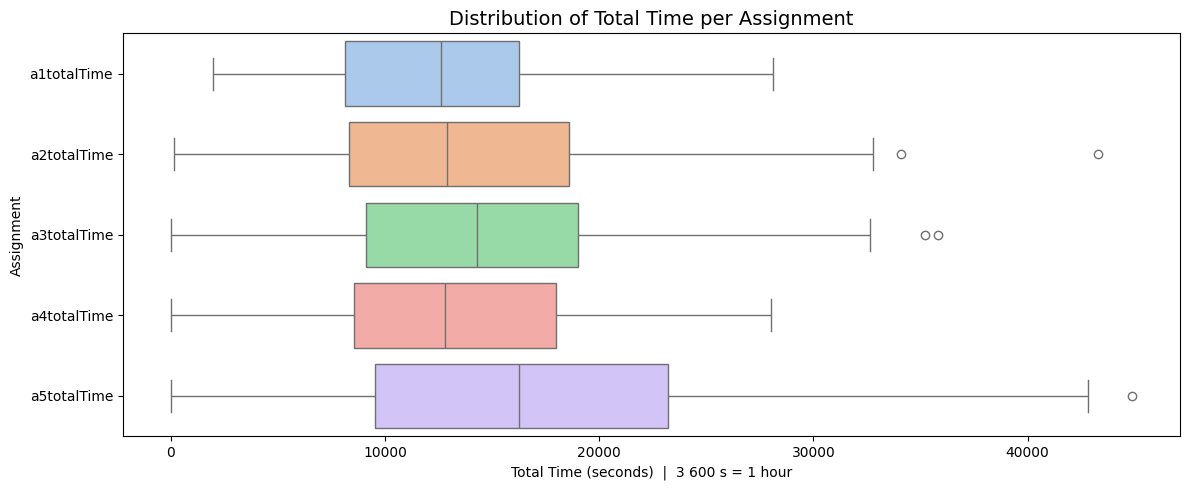

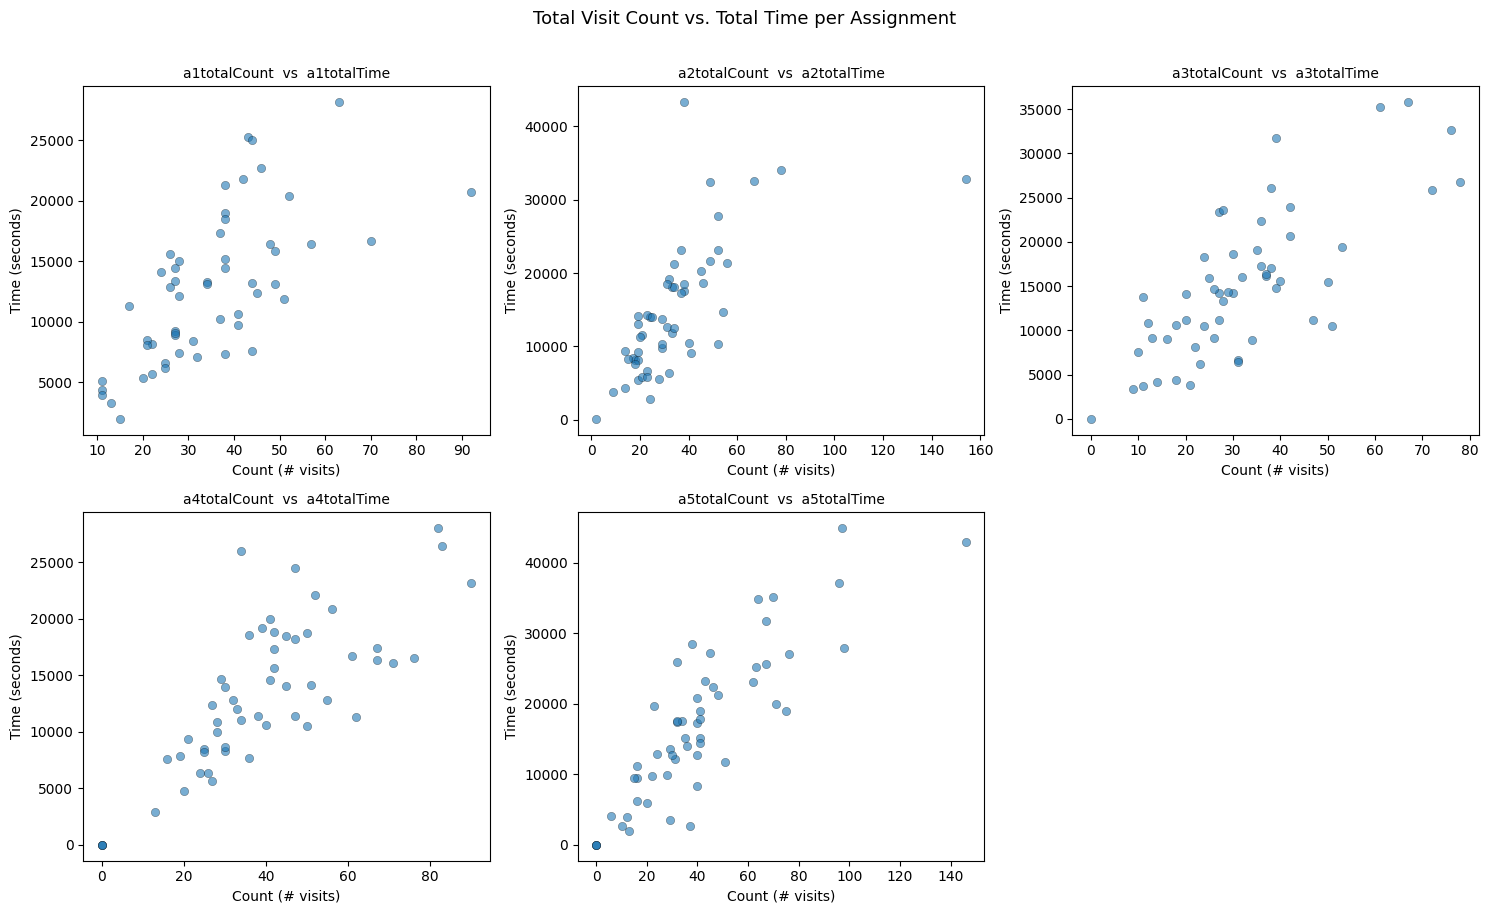

Max total time across all students/assignments: 44873 s = 12.5 hours


In [4]:
# Visualize total time first because time-based LMS data is often skewed.
# The box plot makes it easier to spot assignments or students with unusually large activity.
plt.figure(figsize=(12, 5))
sns.boxplot(data=assignments.filter(like='totalTime'), orient='h', palette='pastel')
plt.title('Distribution of Total Time per Assignment', fontsize=14)
plt.xlabel('Total Time (seconds)  |  3 600 s = 1 hour')
plt.ylabel('Assignment')
plt.tight_layout()
plt.show()

# Compare visit count against total time for each assignment. A strong pattern
# would suggest the two features overlap; scattered points suggest they capture different behaviour.
count_cols = assignments.filter(like='totalCount').columns.tolist()
n = len(count_cols)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, col in enumerate(count_cols):
    time_col = col.replace('totalCount', 'totalTime')
    axes[i].scatter(assignments[col], assignments[time_col], alpha=0.6, edgecolors='k', linewidths=0.3)
    axes[i].set_title(f"{col}  vs  {time_col}", fontsize=10)
    axes[i].set_xlabel('Count (# visits)')
    axes[i].set_ylabel('Time (seconds)')

# Turn off extra axes so the final figure does not show empty panels.
for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Total Visit Count vs. Total Time per Assignment', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Print the maximum as a quick scale check before interpreting the plots.
max_time = assignments.filter(like='totalTime').max().max()
print(f"Max total time across all students/assignments: {max_time:.0f} s = {max_time/3600:.1f} hours")


### Merge with grades and check correlations

Now that we have our first engineered features, let's see if they actually **predict grades**.
We'll merge the feature DataFrame with the grades and compute Pearson correlations.

> 💡 Pearson correlation ranges from −1 (perfect negative) to +1 (perfect positive). 
> A value of 0 means no linear relationship. Correlations around ±0.2–0.4 are already interesting for behavioural data.

In [5]:
# Attach the engineered count/time features to the grade table.
# Keeping grades as the main table makes the next correlation step straightforward.
grades = pd.merge(grades, assignments, on='userID', how='left')

print(f"Grades DataFrame shape: {grades.shape}")
grades.head()


Grades DataFrame shape: (54, 17)


,userID,A1,A2,A3,A4,A5,FinalScore,a1totalCount,a2totalCount,a3totalCount,a4totalCount,a5totalCount,a1totalTime,a2totalTime,a3totalTime,a4totalTime,a5totalTime
0,100001,93.75,68.75,100.00,76.47,82.05,59.97,38,37,37,61,48,18996.0,23123.0,16144.0,16740.0,21227.0
1,100002,112.50,125.00,100.00,88.24,92.31,77.81,46,49,39,42,64,22696.0,32448.0,31711.0,18822.0,34843.0
2,100003,100.00,125.00,121.43,94.12,93.59,89.88,38,33,37,24,29,21270.0,18153.0,16327.0,6363.0,3510.0
3,100004,116.67,125.00,75.00,52.94,57.69,73.30,41,19,38,28,40,9699.0,5456.0,17095.0,10841.0,12777.0
4,100005,95.83,106.25,82.14,35.29,33.33,56.57,27,52,51,27,51,9231.0,10358.0,10529.0,5690.0,11731.0


In [6]:
# For each assignment, compare the grade with the matching total-time feature.
# This is a focused check: A1 is paired with a1totalTime, A2 with a2totalTime, and so on.
correlation_results = {}

for i in range(1, 6):
    grade_col = f'A{i}'
    time_col  = f'a{i}totalTime'
    
    if grade_col in grades.columns and time_col in grades.columns:
        corr = grades[[grade_col, time_col]].corr().iloc[0, 1]
        correlation_results[grade_col] = round(corr, 3)

print("Correlation between assignment grade and total time on that assignment:")
for k, v in correlation_results.items():
    print(f"  {k} <-> {k.lower()}totalTime :  r = {v}")


Correlation between assignment grade and total time on that assignment:
  A1 <-> a1totalTime :  r = 0.351
  A2 <-> a2totalTime :  r = 0.207
  A3 <-> a3totalTime :  r = 0.444
  A4 <-> a4totalTime :  r = 0.551
  A5 <-> a5totalTime :  r = 0.555


These are decent correlations for a behavioural feature.
A2 is the exception — we'd want to investigate the assignment content to understand why.

Let's also look at the **full correlation matrix** across all grade and feature columns to get a wider picture.

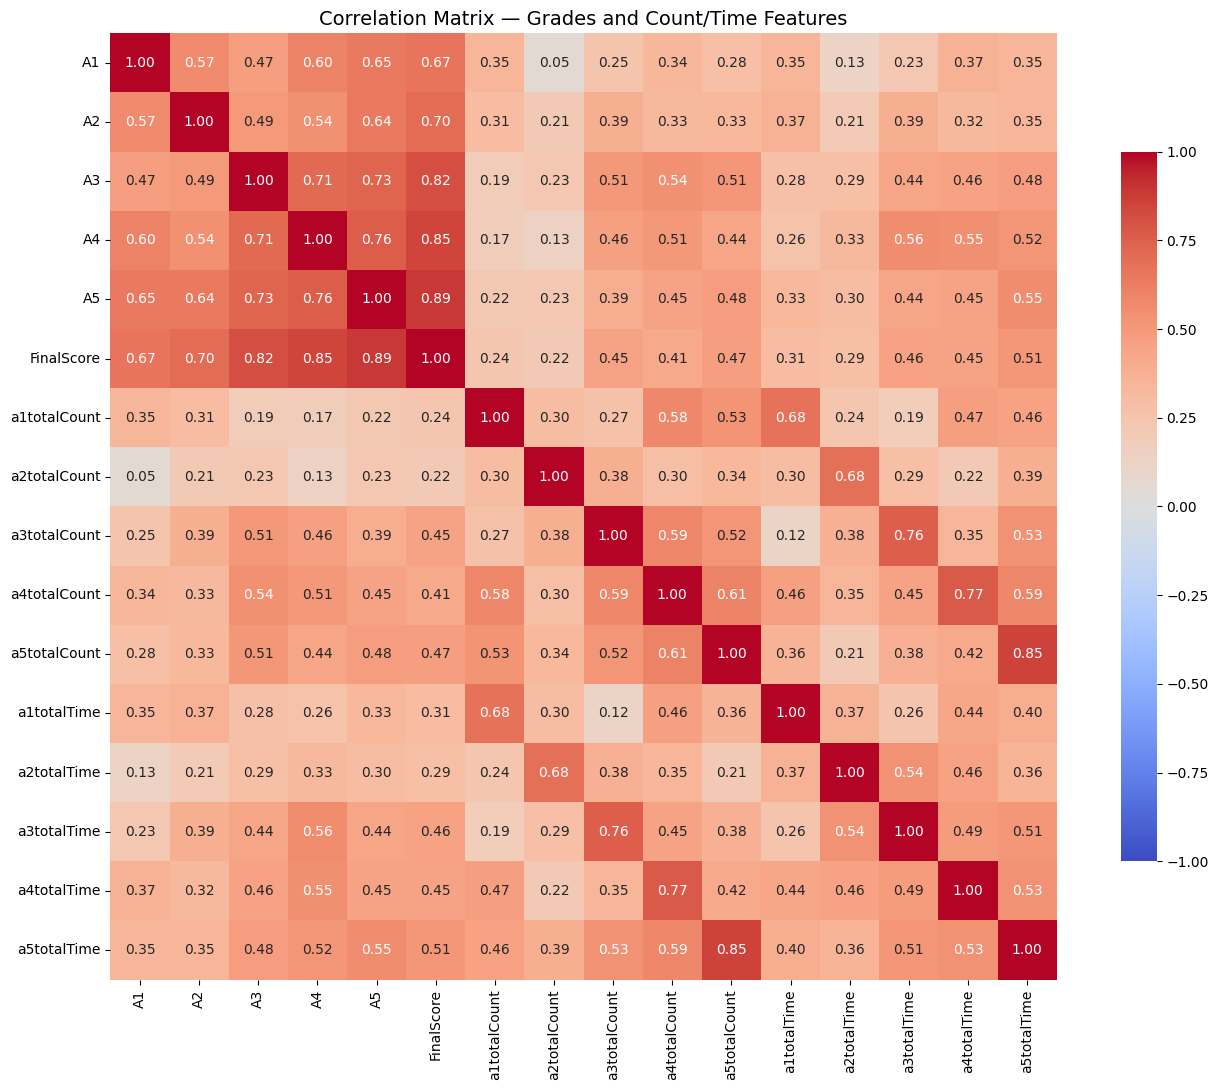


📌 Observation: The correlation between totalCount and totalTime for the same assignment is in the 0.68–0.85 range.
   This means they are related, but NOT redundant — each carries unique information.


In [7]:
# Build a full correlation matrix to check relationships across all numeric columns.
# Dropping userID avoids treating an identifier as if it were a meaningful measurement.
correlation_matrix = grades.drop(columns=['userID']).corr()

plt.figure(figsize=(14, 11))
sns.heatmap(
    correlation_matrix,
    annot=True, fmt=".2f", cmap='coolwarm',
    square=True, cbar_kws={"shrink": .75},
    vmin=-1, vmax=1
)
plt.title('Correlation Matrix — Grades and Count/Time Features', fontsize=14)
plt.tight_layout()
plt.show()

print("\n📌 Observation: The correlation between totalCount and totalTime for the same"
      " assignment is in the 0.68–0.85 range.")
print("   This means they are related, but NOT redundant — each carries unique information.")


---
## Feature Family 2 — Temporal / Day-Based Features

Counts and time tell us *how much* a student engaged. 
But **when** they worked can be equally important:

| Feature | Question answered |
|---|---|
| `firstDay` | How early did they start (days before deadline)? |
| `secondDay` | When did they come back for the second session? |
| `nDays` | Over how many distinct days did they work? |
| `nDaysFinalWeek` | Did they cram everything into the last 7 days? |
| `nDaysAfterDeadline` | Did they access pages after the deadline (late submission risk)? |

> 💡 **Key idea:** A student who starts 14 days before the deadline and works a little each day
> has a very different pattern from one who starts the night before.
> These features give the model a way to capture that difference.

First, we need the **deadline dates** for each assignment.

In [8]:
# Define the assignment deadlines used for all deadline-relative features.
# These timestamps let us describe behaviour as early work, last-week work, or post-deadline activity.
a1deadline = pd.to_datetime('2020-05-27 23:59:00-07:00')
a2deadline = pd.to_datetime('2020-06-15 23:59:00-07:00')
a3deadline = pd.to_datetime('2020-07-05 23:59:00-07:00')
a4deadline = pd.to_datetime('2020-07-15 23:59:00-07:00')
a5deadline = pd.to_datetime('2020-08-09 23:59:00-07:00')

# Use a dictionary so each log row can look up the correct deadline by assignment label.
deadlines = {
    'a1': a1deadline,
    'a2': a2deadline,
    'a3': a3deadline,
    'a4': a4deadline,
    'a5': a5deadline,
}

print("Deadlines loaded:")
for k, v in deadlines.items():
    print(f"  {k}: {v.date()}")


Deadlines loaded:
  a1: 2020-05-27
  a2: 2020-06-15
  a3: 2020-07-05
  a4: 2020-07-15
  a5: 2020-08-09


Now we loop over every (student, assignment) group in the log to compute the temporal features.

The key formula is:
```
days_before_deadline = (deadline.date() - access_date).days
```
A positive number means the student accessed the page **before** the deadline.
A negative number means they accessed it **after** — which might indicate late work or reviewing feedback.

In [9]:
# Convert start_time into timezone-aware datetimes so date comparisons are reliable.
log['start_time'] = pd.to_datetime(log['start_time'], utc=True)

# Keep only the calendar date for features that care about days rather than exact times.
log['date'] = log['start_time'].dt.date

# Create one temporal-behaviour summary row per student and assignment.
rows = []

for (user, assignment), group in log.groupby(['userID', 'assignment']):
    # Ignore any assignment labels that do not have a deadline defined above.
    if assignment not in deadlines:
        continue
    
    deadline = deadlines[assignment]
    
    # Collapse many page views into the unique days when the student was active.
    dates = sorted(set(group['date']))
    
    # Express each activity day relative to the deadline.
    # Larger positive values mean earlier access; negative values mean after the deadline.
    days_before = [(deadline.date() - d).days for d in dates]
    
    # Count activity concentrated near the deadline as a rough cramming signal.
    days_in_last_week = [d for d in dates if 0 <= (deadline.date() - d).days <= 7]
    
    rows.append({
        'userID':              user,
        'assignment':          assignment,

        # First observed access, measured in days before the deadline.
        'firstDay':            days_before[0] if len(days_before) >= 1 else None,

        # Second distinct activity day, useful for seeing whether the student came back.
        'secondDay':           days_before[1] if len(days_before) >= 2 else None,

        # Difference between the first two activity days; later dropped because it is derived.
        'firstSecondGap':      (days_before[0] - days_before[1]) if len(days_before) >= 2 else None,

        # Number of unique active days for this assignment.
        'nDays':               len(dates),

        # Number of active days during the final week before the deadline.
        'nDaysFinalWeek':      len(days_in_last_week),

        # Number of active days earlier than the final week.
        'nDaysBeforeFinalWeek': len([d for d in days_before if d > 7]),

        # Number of active days after the official deadline.
        'nDaysAfterDeadline':  len([d for d in days_before if d < 0]),
    })

activity_summary = pd.DataFrame(rows)
print(f"activity_summary shape: {activity_summary.shape}")
activity_summary.head(10)


activity_summary shape: (263, 9)


,userID,assignment,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,-2184,-2187.0,3.0,7,0,0,7
1,100001,a2,-2173,-2179.0,6.0,11,0,0,11
2,100001,a3,-2181,-2185.0,4.0,9,0,0,9
3,100001,a4,-2187,-2188.0,1.0,9,0,0,9
4,100001,a5,-2176,-2177.0,1.0,8,0,0,8
5,100002,a1,-2175,-2182.0,7.0,9,0,0,9
6,100002,a2,-2172,-2173.0,1.0,14,0,0,14
7,100002,a3,-2173,-2176.0,3.0,13,0,0,13
8,100002,a4,-2185,-2189.0,4.0,6,0,0,6
9,100002,a5,-2164,-2167.0,3.0,14,0,0,14


### Reshaping the data: wide vs. long format

Right now `grades` is in **wide format** (one row per student, one column per assignment per feature).
`activity_summary` is in **long format** (one row per student–assignment pair).

To cleanly merge temporal features with grades, we'll convert everything to long format first.

> 💡 `pd.melt()` is the pandas function for converting from wide to long.
> It "unpivots" selected columns into rows.

In [10]:
# Reshape the wide grade/feature table into long format.
# Long format gives one row per student-assignment pair, which is easier to join with day-based features.
counts_long = grades.melt(
    id_vars='userID',
    value_vars=[f'a{i}totalCount' for i in range(1, 6)],
    var_name='assignment',
    value_name='totalCount'
)
# Strip feature suffixes so the assignment labels match the rest of the notebook.
counts_long['assignment'] = counts_long['assignment'].str.extract(r'(a\d)')

# Repeat the same reshape for total time.
times_long = grades.melt(
    id_vars='userID',
    value_vars=[f'a{i}totalTime' for i in range(1, 6)],
    var_name='assignment',
    value_name='totalTime'
)
times_long['assignment'] = times_long['assignment'].str.extract(r'(a\d)')

# Recombine count and time after both have the same long-format keys.
activity_totals = pd.merge(counts_long, times_long, on=['userID', 'assignment'])

# Map each assignment label to its grade column so each long-format row gets the correct score.
assignment_to_grade_col = {f'a{i}': f'A{i}' for i in range(1, 6)}

activity_totals['grade'] = activity_totals.apply(
    lambda row: grades.loc[
        grades['userID'] == row['userID'],
        assignment_to_grade_col[row['assignment']]
    ].values[0],
    axis=1
)

# Add the overall course grade as context alongside each assignment row.
activity_totals = pd.merge(activity_totals, grades[['userID','FinalScore']], on='userID', how='left')

# Put identifiers and outcomes first, followed by engineered activity measures.
activity_totals = activity_totals[['userID','assignment','grade','FinalScore','totalCount','totalTime']]

print(f"activity_totals shape: {activity_totals.shape}")
activity_totals.head()


activity_totals shape: (270, 6)


,userID,assignment,grade,FinalScore,totalCount,totalTime
0,100001,a1,93.75,59.97,38,18996.0
1,100002,a1,112.50,77.81,46,22696.0
2,100003,a1,100.00,89.88,38,21270.0
3,100004,a1,116.67,73.30,41,9699.0
4,100005,a1,95.83,56.57,27,9231.0


Now merge the temporal features into our long-format dataset.

In [11]:
# Join the activity totals with the deadline-relative day features.
# Both tables are keyed by userID and assignment, so the merge preserves one row per student-assignment.
grades2 = pd.merge(activity_totals, activity_summary, on=['userID', 'assignment'], how='left')

print(f"grades2 shape: {grades2.shape}")
print("Columns:", grades2.columns.tolist())
grades2.head()


grades2 shape: (270, 13)
Columns: ['userID', 'assignment', 'grade', 'FinalScore', 'totalCount', 'totalTime', 'firstDay', 'secondDay', 'firstSecondGap', 'nDays', 'nDaysFinalWeek', 'nDaysBeforeFinalWeek', 'nDaysAfterDeadline']


,userID,assignment,grade,FinalScore,totalCount,totalTime,firstDay,secondDay,firstSecondGap,nDays,nDaysFinalWeek,nDaysBeforeFinalWeek,nDaysAfterDeadline
0,100001,a1,93.75,59.97,38,18996.0,-2184.0,-2187.0,3.0,7.0,0.0,0.0,7.0
1,100002,a1,112.50,77.81,46,22696.0,-2175.0,-2182.0,7.0,9.0,0.0,0.0,9.0
2,100003,a1,100.00,89.88,38,21270.0,-2179.0,-2185.0,6.0,7.0,0.0,0.0,7.0
3,100004,a1,116.67,73.30,41,9699.0,-2185.0,-2190.0,5.0,5.0,0.0,0.0,5.0
4,100005,a1,95.83,56.57,27,9231.0,-2185.0,-2186.0,1.0,6.0,0.0,0.0,6.0


## Correlation matrix: all features vs. grades

Let's see how well our temporal features correlate with each assignment grade.

Because our data is now in long format, we first need to pivot it back to wide format
so that each column corresponds to one (feature, assignment) combination —
that's what we need for a heatmap.

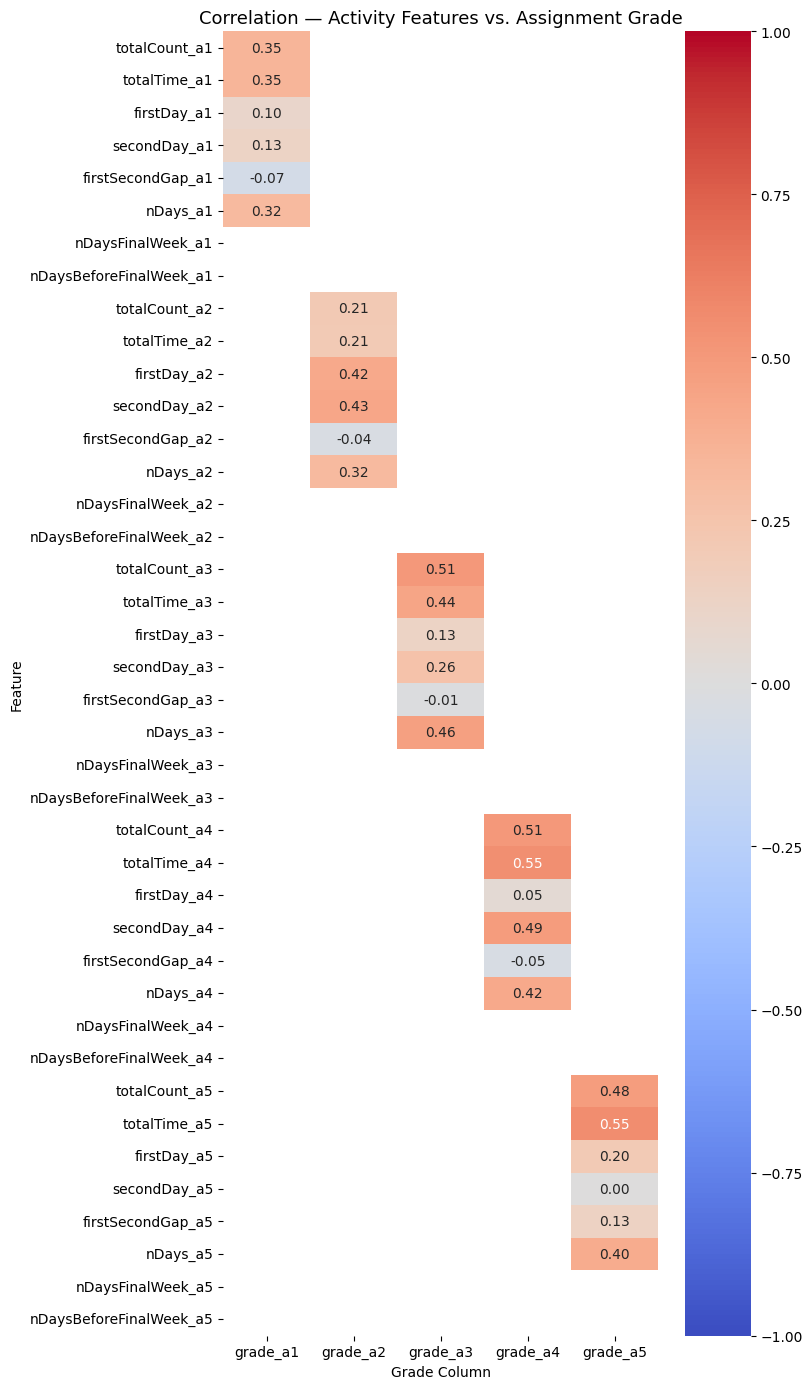


📌 Note: 'firstSecondGap' can be computed from firstDay and secondDay,
   making it redundant (collinear). We'll drop it and 'nDaysBeforeFinalWeek' next.


In [12]:
# Pivot back to wide format only for the heatmap.
# The modelling data stays long, but the heatmap needs one feature column per assignment.
grades_wide = grades2.pivot(index='userID', columns='assignment')
grades_wide.columns = [f"{col[0]}_{col[1]}" for col in grades_wide.columns]
grades_wide = grades_wide.reset_index()

# Define the grade columns and feature families to compare.
grade_cols    = [f'grade_a{i}' for i in range(1, 6)]
assignments_  = ['a1', 'a2', 'a3', 'a4', 'a5']
feature_bases = ['totalCount','totalTime','firstDay','secondDay',
                 'firstSecondGap','nDays','nDaysFinalWeek',
                 'nDaysBeforeFinalWeek']

feature_cols  = [
    f"{feat}_{a}"
    for a in assignments_
    for feat in feature_bases
    if f"{feat}_{a}" in grades_wide.columns
]

# Correlate each assignment's features only with that same assignment's grade.
# This keeps the interpretation focused instead of mixing behaviours across assignments.
corr_matrix = pd.DataFrame(index=feature_cols, columns=grade_cols, dtype='float')

for a in assignments_:
    grade_col = f'grade_{a}'
    for feat in feature_bases:
        feat_col = f'{feat}_{a}'
        if grade_col in grades_wide.columns and feat_col in grades_wide.columns:
            corr_matrix.loc[feat_col, grade_col] = (
                grades_wide[[grade_col, feat_col]].corr().iloc[0, 1]
            )

corr_matrix = corr_matrix.astype(float)

# Plot the same-assignment correlations so the strongest feature/grade patterns stand out.
plt.figure(figsize=(8, 14))
sns.heatmap(
    corr_matrix, annot=True, cmap='coolwarm', center=0,
    fmt=".2f", vmin=-1, vmax=1
)
plt.title("Correlation — Activity Features vs. Assignment Grade", fontsize=13)
plt.xlabel("Grade Column")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

print("\n📌 Note: 'firstSecondGap' can be computed from firstDay and secondDay,")
print("   making it redundant (collinear). We'll drop it and 'nDaysBeforeFinalWeek' next.")


Some features are **redundant** (collinear): `firstSecondGap` can always be derived from `firstDay` and `secondDay`.
Keeping redundant features in a regression model can cause instability.
Let's drop them.

In [13]:
# Remove features that add little independent information.
# firstSecondGap is calculated from existing columns, while nDaysBeforeFinalWeek
# overlaps heavily with the total active-day and final-week counts.
grades2 = grades2.drop(columns=['firstSecondGap', 'nDaysBeforeFinalWeek'])

print("Remaining columns:")
grades2.info()


Remaining columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   userID              270 non-null    int64  
 1   assignment          270 non-null    object 
 2   grade               270 non-null    float64
 3   FinalScore          270 non-null    float64
 4   totalCount          270 non-null    int64  
 5   totalTime           270 non-null    float64
 6   firstDay            263 non-null    float64
 7   secondDay           262 non-null    float64
 8   nDays               263 non-null    float64
 9   nDaysFinalWeek      263 non-null    float64
 10  nDaysAfterDeadline  263 non-null    float64
dtypes: float64(8), int64(2), object(1)
memory usage: 23.3+ KB


---
## Feature Family 3 — Ratios

Counts and totals answer *how much*. Ratios answer *what proportion*.

Consider:
- Student A spent 2 hours on the assignment and 1 hour on the detail spec page → **50% detail ratio**
- Student B spent 10 hours on the assignment and 1 hour on the detail spec page → **10% detail ratio**

Both spent the same absolute time on the detail page, but Student B spread their effort much more broadly.
A ratio feature captures this relative behaviour.

We will compute: **`detailRatio`** = (time spent on detail pages) / (total time on all assignment pages)

> 💡 A Canvas assignment typically has several pages. The **detail** page contains the full specification.
> Students who spend more relative time on the spec may be doing more careful reading.

In [14]:
# Focus on assignment detail pages, which are likely to contain the actual instructions/specs.
# This separates time spent reading the assignment brief from general navigation activity.
detail_pattern = r'a[1-5]-detail'
log_detail = log[log['url'].str.contains(detail_pattern, regex=True, na=False)]

print(f"Total log rows:        {len(log):,}")
print(f"Detail-page rows only: {len(log_detail):,}  ({100*len(log_detail)/len(log):.1f}%)")

# Add up detail-page time for each student-assignment pair.
detail_time = (
    log_detail
    .groupby(['userID', 'assignment'])['view_length']
    .sum()
    .reset_index()
    .rename(columns={'view_length': 'detailTime'})
)

print(f"\ndetail_time shape: {detail_time.shape}")
detail_time.head()


Total log rows:        9,829
Detail-page rows only: 2,303  (23.4%)

detail_time shape: (262, 3)


,userID,assignment,detailTime
0,100001,a1,8745.0
1,100001,a2,15355.0
2,100001,a3,12559.0
3,100001,a4,9388.0
4,100001,a5,7512.0


detailRatio distribution:
count    270.000
mean       0.518
std        0.249
min        0.000
25%        0.352
50%        0.537
75%        0.717
max        0.992
Name: detailRatio, dtype: float64


/var/folders/gz/ks34dzcs0j5bsr2wvypj7fj80000gn/T/ipykernel_8532/400153031.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


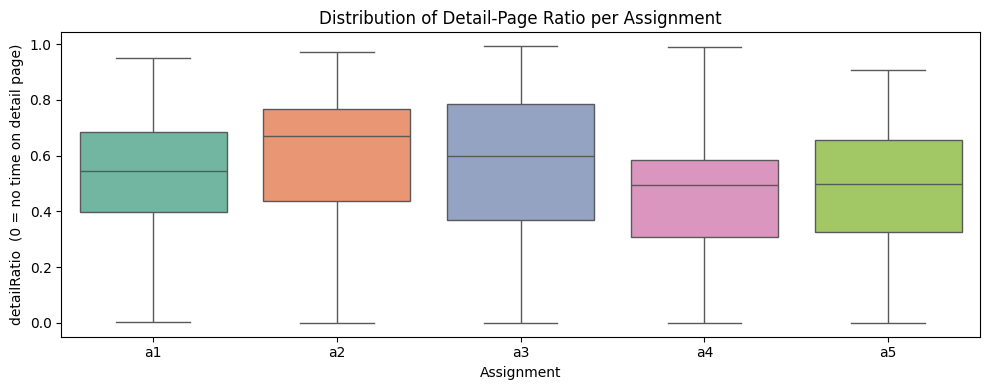

In [15]:
# Add detail-page time to the main long-format feature table.
# Missing values mean no matching detail-page visits were recorded for that student-assignment.
grades2 = pd.merge(grades2, detail_time, on=['userID', 'assignment'], how='left')

# Convert raw detail time into a proportion of total time.
# This normalizes students with very different total activity levels.
grades2['detailRatio'] = grades2['detailTime'] / grades2['totalTime']
grades2['detailRatio'] = grades2['detailRatio'].fillna(0)

print("detailRatio distribution:")
print(grades2['detailRatio'].describe().round(3))

# Plot the ratio by assignment to see whether some assignments drove more detail-page reading.
plt.figure(figsize=(10, 4))
sns.boxplot(
    data=grades2, x='assignment', y='detailRatio',
    order=['a1','a2','a3','a4','a5'], palette='Set2'
)
plt.title('Distribution of Detail-Page Ratio per Assignment')
plt.xlabel('Assignment')
plt.ylabel('detailRatio  (0 = no time on detail page)')
plt.tight_layout()
plt.show()


Let's check whether `detailRatio` correlates with grades.

In [16]:
# Measure whether students with a higher detail-page ratio also earned higher grades.
# The loop keeps each assignment separate because the relationship may differ by task.
correlations = {}
for assignment in sorted(grades2['assignment'].unique()):
    subset = grades2[grades2['assignment'] == assignment]
    if subset['detailRatio'].nunique() > 1:
        corr = subset[['grade', 'detailRatio']].corr().iloc[0, 1]
        correlations[assignment] = round(corr, 3)
    else:
        correlations[assignment] = None

corr_df = pd.DataFrame.from_dict(
    correlations, orient='index', columns=['Correlation with grade']
)
corr_df.index.name = 'Assignment'
print(corr_df)

print("\n📌 Positive correlations throughout — students who spend a higher proportion")
print("   of their time reading the spec tend to score better.")
print("   A2 and A5 are especially strong — worth investigating the assignment content!")


            Correlation with grade
Assignment                        
a1                           0.116
a2                           0.369
a3                           0.145
a4                           0.121
a5                           0.315

📌 Positive correlations throughout — students who spend a higher proportion
   of their time reading the spec tend to score better.
   A2 and A5 are especially strong — worth investigating the assignment content!


---
## Putting it all together — Linear Regression

Now that we have three families of features, let's fit a simple **multiple linear regression** model
to predict each assignment grade.

This is not the main focus of today's lecture, but it gives us a concrete way to evaluate
whether our feature engineering paid off:
- **R²** — what percentage of grade variance do our features explain?
- **RMSE** — on average, how many grade points is our prediction off by?
- **Coefficients** — which features are most influential?

> ⚠️ **Important:** We are fitting on the full dataset (no train/test split) just to get a feel for the features.
> In a proper study you would use cross-validation (see the `LeaveOneOut` import below).

Let's run a separate model for each assignment.

Note: `totalTime` is in **seconds**, which is a very large number compared to a grade (0–100).
The coefficient printed will look like 0.000, not because time has no effect,
but because one extra *second* barely moves the grade.
We'll convert to hours to make the coefficient interpretable.

### Interpreting the model

**How to read the coefficients:**
- A coefficient of `+2.5` on `firstDay` means: *for every extra day earlier a student started, the model predicts 2.5 more grade points* (all else being equal).
- A coefficient of `−5.6` on `nDaysAfterDeadline` means: *each day a student accessed pages after the deadline is associated with −5.6 grade points* — possibly indicating late or incomplete submissions.

**Why R² is modest (~0.25):**
> This model has no information about the student's background or programming skill.
> A strong programmer might spend very little time on Canvas yet score 95.
> A struggling student might spend many hours yet score 40.
> Our behavioural features alone can explain about 25% of the variance — which is actually meaningful given what we're working with!

---
## Summary: What we did today

| Step | Action | Pandas / sklearn tool |
|---|---|---|
| 1 | Counted page views per student per assignment | `groupby().size().unstack()` |
| 2 | Summed time spent per student per assignment | `groupby()[col].sum().unstack()` |
| 3 | Computed temporal features (days before deadline) | Manual loop + `pd.DataFrame` |
| 4 | Reshaped data from wide to long | `pd.melt()` + `pd.merge()` |
| 5 | Computed ratio feature (detail page proportion) | Column arithmetic |
| 6 | Evaluated all features with correlation heatmap | `.corr()` + `sns.heatmap()` |
| 7 | Dropped redundant/collinear features | `df.drop(columns=[...])` |
| 8 | Fit linear regression to assess predictive power | `sklearn.LinearRegression` |

**Key takeaways:**
- Feature engineering turns raw events into model-ready inputs using domain knowledge.
- Always **visualise and check correlations** before using features in a model.
- **Redundant features** (those that can be derived from others) should be removed to avoid collinearity.
- **Scale matters**: a feature in seconds and a feature in counts are on very different scales — consider normalising or converting units before interpreting coefficients.